# 01 Importing Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# 02 Import Data

In [2]:
path = r'C:\Users\isava\OneDrive\Documents\CareerFoundry\Data Immersion\PythonFundamentals\Instacart Basket Analysis'
path

'C:\\Users\\isava\\OneDrive\\Documents\\CareerFoundry\\Data Immersion\\PythonFundamentals\\Instacart Basket Analysis'

In [3]:
df = pd.read_pickle(os.path.join(path,'02 Data', 'Prepared Data','ords_prods_custs.pkl'))

In [6]:
df.head()

,order_id,user_id,order_number,orders_day_of_week,order_time_of_day,days_since_users_prior_order,product_id,add_to_cart_order,reordered,_merge,...,first_name,last_name,gender,state,age,date_joined,n_dependents,fam_status,income,_custMerge
0,2539329,1,1,2,8,NaN,196,1,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both
1,3367565,1,6,2,7,19.0,25133,4,1,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both
2,550135,1,7,1,9,20.0,196,1,1,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both
3,550135,1,7,1,9,20.0,10258,2,1,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both
4,550135,1,7,1,9,20.0,12427,3,1,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,both


# 03 Visualizations

## Barplots

<Axes: xlabel='orders_day_of_week'>

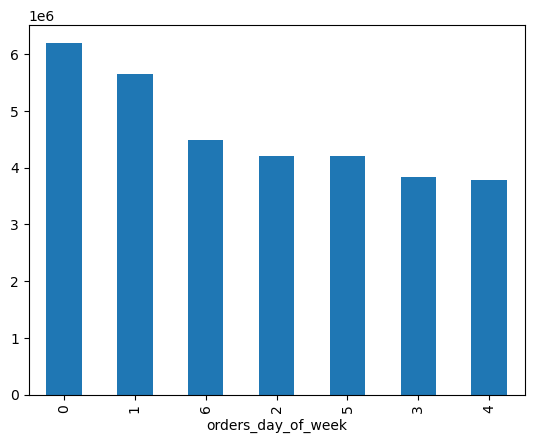

In [9]:
df['orders_day_of_week'].value_counts().plot.bar()

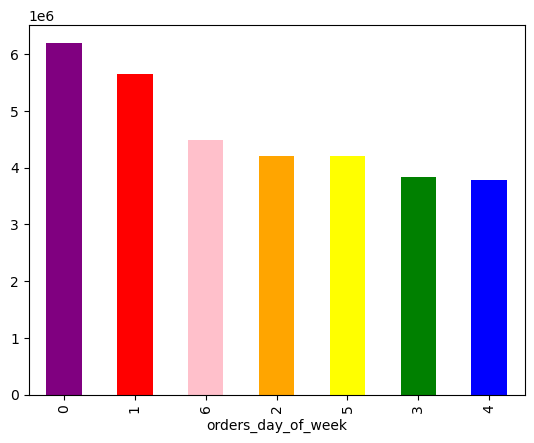

In [10]:
bar = df['orders_day_of_week'].value_counts().plot.bar(color =['purple', 'red', 'pink', 'orange', 'yellow', 'green', 'blue'])

In [11]:
bar.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_orders_dow.png'))

## Histograms and Scatterplots

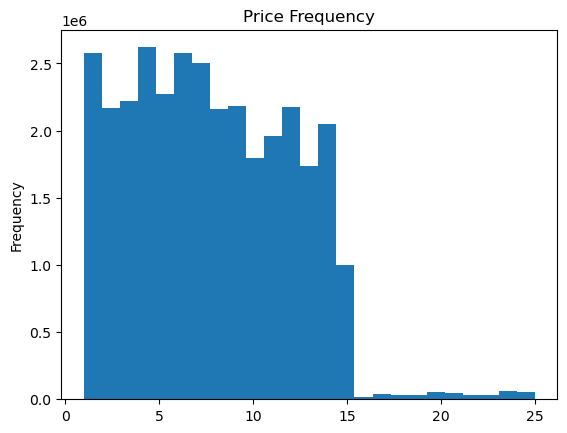

In [7]:
hist = df['prices'].plot.hist(bins = 25, title = "Price Frequency")

In [8]:
hist.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'hist_prices.png'))

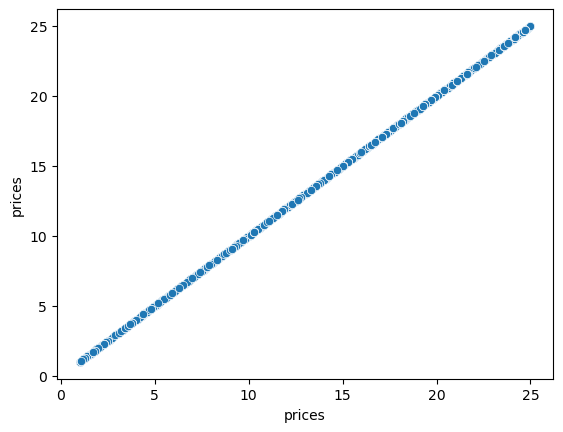

In [15]:
scatter = sns.scatterplot(x = 'prices', y = 'prices',data = df)

In [16]:
scatter.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'scatter_prices.png'))

## Linecharts

The data set is too large so we will need to use sampling. 

### Sampling

In [15]:
np.random.seed(4)
dev = np.random.rand(len(df)) <= 0.7
big = df[dev]
small = df[~dev]

In [16]:
df_2 = small[['orders_day_of_week','prices']]

### Chart

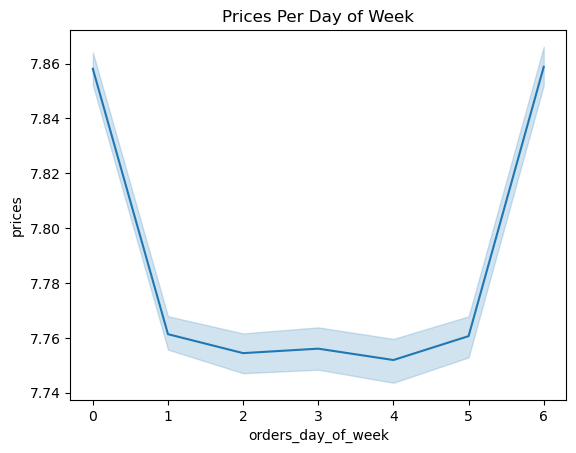

In [18]:
line = sns.lineplot(data = df_2, x = 'orders_day_of_week',y = 'prices').set(title = "Prices Per Day of Week")

In [24]:
line

[Text(0.5, 1.0, 'Prices Per Day of Week')]

In [22]:
line.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'scatter_prices_ordersdow.png'))

AttributeError: 'list' object has no attribute 'figure'

# 04 Excercises

You need to provide the Instacart senior stakeholders with descriptive findings about sales. Create a histogram of the “order_hour_of_day” column.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32404859 entries, 0 to 32404858
Data columns (total 35 columns):
 #   Column                        Dtype   
---  ------                        -----   
 0   order_id                      int32   
 1   user_id                       int32   
 2   order_number                  int8    
 3   orders_day_of_week            int8    
 4   order_time_of_day             int8    
 5   days_since_users_prior_order  float16 
 6   product_id                    int32   
 7   add_to_cart_order             int32   
 8   reordered                     int8    
 9   _merge                        category
 10  product_name                  object  
 11  aisle_id                      int8    
 12  department_id                 int8    
 13  prices                        float64 
 14  _prodMerge                    category
 15  price_range_loc               category
 16  busiest_day                   category
 17  busiest_days                  category
 18  

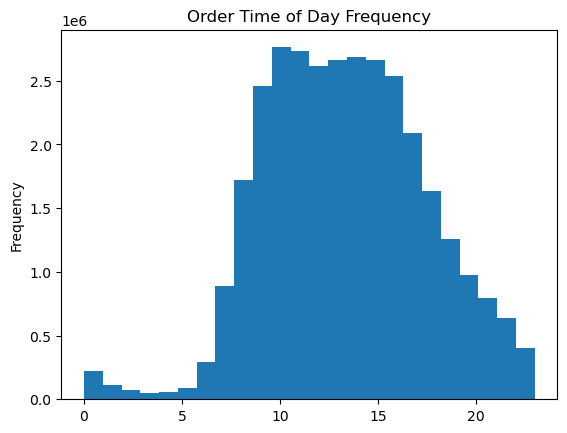

In [26]:
hist2 = df['order_time_of_day'].plot.hist(bins = 24, title = "Order Time of Day Frequency")

I used 24 bins so each hour of the day would have its own bin. At around 7 am the orders start becoming more frequent and peak around the 10 am. They start reducing signficantly around 10 pm.

In [28]:
hist2.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'hist_order_tod.png'))

The marketing team is curious about the distribution of orders among customers in terms of loyalty. Create a bar chart from the “loyalty_flag” column.

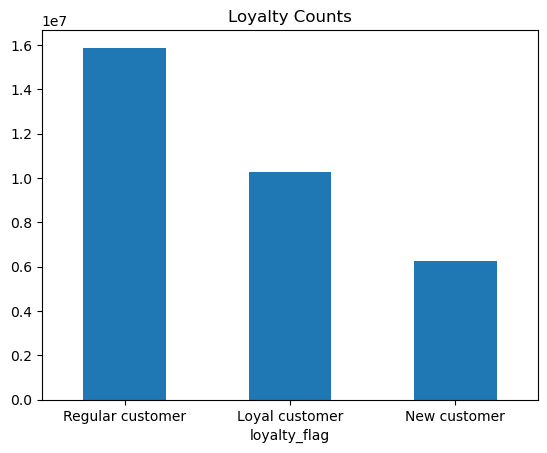

In [30]:
bar2 = df['loyalty_flag'].value_counts().plot.bar(rot = 0, title = 'Loyalty Counts')

There are mostly regular customers. There are less new customers.

In [32]:
bar2.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_loyalty_flag.png'))

Check whether there’s a difference in expenditure (the “prices” column) depending on the hour of the day. Using sample data.

In [ ]:
df_3 = small[['order_time_of_day','prices']]
line3 = sns.lineplot(data = df_3, x = 'order_time_of_day',y = 'prices').set(title = 'Prices Per Time of Day')

Interstingly, despite there be less orders in the early hours of the morning, these are the times when customers buy pricier items. One possible reason could be a lack of other options at this time or if there are orders being made its due to an emergency like pharmecuetical items.

In [38]:
line3.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'line_order_tod_prices.png'))

Determine whether there’s a connection between age and family situation by creating a line chart exploring the connections between age and number of dependents

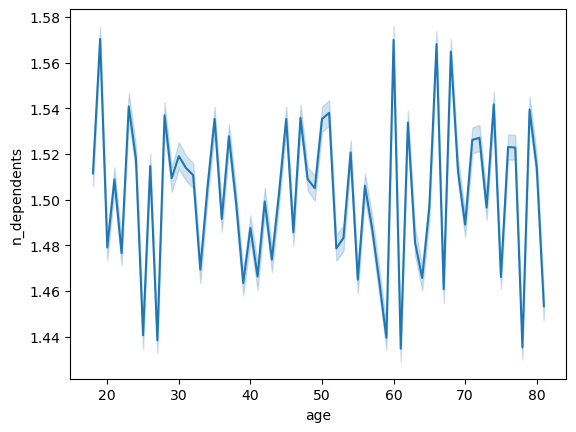

In [40]:
df_4 = small[['age','n_dependents']]
line4 = sns.lineplot(data = df_4, x = 'age',y = 'n_dependents').set(title = 'Dependents Per Age')

The distribution between age and dependents imploes no connection.

In [42]:
line4.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'line_age_n_dependents.png'))

You’ll also need to explore whether there’s a connection between age and spending power (income). To visualize this relationship, create a scatterplot using the sns.scatterplot() function.

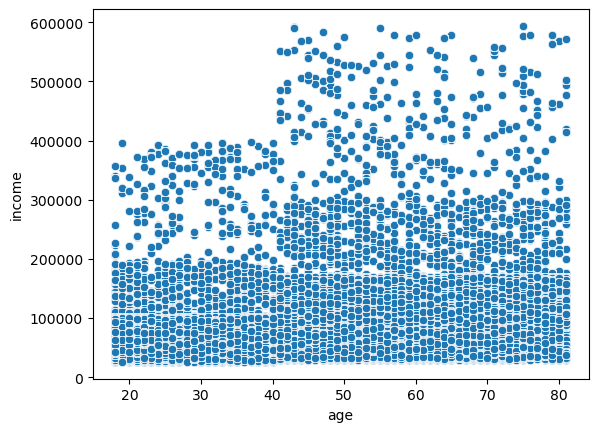

In [44]:
df_5 = small[['age','income']]
scatter2 = sns.scatterplot(data = df_5, x = 'age',y = 'income')

There does seem to be higher income in the older age groups.

In [46]:
scatter2.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'scatter_age_income.png'))